<a href="https://colab.research.google.com/github/kevinandrespardo2506-boop/inteligencia-artificial-2/blob/main/Prediccion_Colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Descarga y Análisis del Notebook Original de GitHub

Vamos a descargar el archivo `.ipynb` desde el repositorio de GitHub especificado para inspeccionar su estructura y entender el dataset y los modelos aplicados originalmente.

In [1]:
import urllib.request
import json

# URL del archivo raw en GitHub
github_raw_url = "https://raw.githubusercontent.com/kevinandrespardo2506-boop/inteligencia-artificial-2/main/Actividaddatosd.ipynb"
filename = "Actividaddatosd.ipynb"

try:
    urllib.request.urlretrieve(github_raw_url, filename)
    print("¡Notebook descargado con éxito!")

    # Leemos el contenido básico para entender la estructura de celdas
    with open(filename, 'r', encoding='utf-8') as f:
        nb_data = json.load(f)

    print(f"El notebook contiene {len(nb_data['cells'])} celdas.")
except Exception as e:
    print(f"Error al descargar o leer el notebook: {e}")

¡Notebook descargado con éxito!
El notebook contiene 16 celdas.


In [2]:
# Analizar el contenido del notebook para identificar las variables y lógica clave
with open('Actividaddatosd.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

print("=== RESUMEN DE CELDAS DE CÓDIGO DEL NOTEBOOK ORIGINAL ===")
code_cells_count = 0
for idx, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code_cells_count += 1
        # Mostrar las primeras líneas de cada celda de código relevante
        source_lines = cell['source']
        snippet = "".join(source_lines[:6])
        print(f"\n[Celda de Código #{code_cells_count}] (Index {idx}):")
        print(snippet + "\n..." if len(source_lines) > 6 else snippet)

=== RESUMEN DE CELDAS DE CÓDIGO DEL NOTEBOOK ORIGINAL ===

[Celda de Código #1] (Index 2):
# imports
import pandas as pd
import matplotlib.pyplot as plt

# url
url_datos = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

...

[Celda de Código #2] (Index 3):
# Muestro las primeras 5 filas del DataFrame para verificar que los datos se hayan cargado correctamente.
df.head()

[Celda de Código #3] (Index 4):
# Reviso la cantidad de filas y columnas que contiene el conjunto de datos para entender su tamaño.
print("Dimensiones del dataset:", df.shape)

# Verifico si existen valores nulos por columna para saber si es necesario realizar imputación de datos.
# Esto es crucial para la calidad del modelo, ya que muchos algoritmos no manejan valores faltantes.
print("\nValores nulos por columna:\n", df.isnull().sum())

[Celda de Código #4] (Index 5):
# Elijo la variable objetivo a predecir; en este caso 'medv' representa el valor medio de la vivienda.
y = df['medv']

#

### 2. Generación del Dataset de Viviendas en Bogotá

Crearemos un dataset simulado altamente realista que represente la distribución del mercado inmobiliario en Bogotá, mapeando factores clave como el estrato y el tamaño de la propiedad.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configuración de reproducibilidad
np.random.seed(42)

# Generación de datos sintéticos representativos de Bogotá (500 viviendas)
n_samples = 500

estrato = np.random.choice([2, 3, 4, 5, 6], size=n_samples, p=[0.25, 0.35, 0.20, 0.12, 0.08])
area_m2 = np.random.normal(loc=75 + 15 * (estrato - 2), scale=20, size=n_samples).clip(30, 300)
habitaciones = (area_m2 / 25 + np.random.normal(0, 0.7, n_samples)).astype(int).clip(1, 5)
distancia_centro_km = np.random.uniform(2, 25, size=n_samples)

# Generamos el precio en Millones de COP correlacionado con las variables
# Un precio base + incrementos significativos por estrato, área y penalización por distancia
precio_base = 80
precio_m2 = 2.8 * (estrato * 0.8)
precio_cop = (
    precio_base
    + area_m2 * precio_m2
    + habitaciones * 15
    - distancia_centro_km * 2.5
    + np.random.normal(0, 35, n_samples)
).clip(60, 1200) # Precios de 60M a 1200M COP

# Definir el dataset de Bogotá
df_bogota = pd.DataFrame({
    'Estrato': estrato,
    'Area_m2': area_m2,
    'Habitaciones': habitaciones,
    'Distancia_Centro_Km': distancia_centro_km,
    'Precio_COP_Millones': precio_cop
})

# Definimos la variable objetivo binaria para la Regresión Logística
# Vivienda Premium: Precio mayor a 450 Millones de COP
umbral_premium = 450
df_bogota['Vivienda_Premium'] = (df_bogota['Precio_COP_Millones'] > umbral_premium).astype(int)

df_bogota.head()

,Estrato,Area_m2,Habitaciones,Distancia_Centro_Km,Precio_COP_Millones,Vivienda_Premium
0,3,96.835120,4,16.643403,699.902385,1
1,6,172.523417,5,16.120472,1200.000000,1
2,4,124.008477,5,3.532997,1200.000000,1
3,3,78.461927,3,13.923385,644.057646,1
4,2,57.031707,2,5.453887,354.752719,0


### 3. Entrenamiento y Evaluación de Modelos

Dividiremos los datos en entrenamiento y prueba para entrenar tanto la **Regresión Lineal** (para predecir el valor exacto) como la **Regresión Logística** (para clasificar si es Premium).

In [4]:
# Variables Predictoras
X = df_bogota[['Estrato', 'Area_m2', 'Habitaciones', 'Distancia_Centro_Km']]

# Variables Objetivo
y_continuous = df_bogota['Precio_COP_Millones']
y_binary = df_bogota['Vivienda_Premium']

# División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train_cont, y_test_cont, y_train_bin, y_test_bin = train_test_split(
    X, y_continuous, y_binary, test_size=0.20, random_state=42
)

# 1. Regresión Lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train_cont)
pred_lineal_cont = modelo_lineal.predict(X_test)

# Clasificación derivada de la regresión lineal utilizando el umbral de 450M COP
pred_lineal_bin = (pred_lineal_cont > umbral_premium).astype(int)

# 2. Regresión Logística
modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train_bin)
pred_logistica_bin = modelo_logistico.predict(X_test)
pred_logistica_proba = modelo_logistico.predict_proba(X_test)[:, 1]

### 4. Cuadros de Comparación y Tablas de Métricas

Generaremos los cuadros comparativos de rendimiento tanto bajo el enfoque de **Regresión (Precios continuos)** como bajo el enfoque de **Clasificación (Vivienda Premium)**.

In [5]:
# --- CUADRO 1: Métricas de Regresión (Regresión Lineal) ---
mae_lr = mean_absolute_error(y_test_cont, pred_lineal_cont)
mse_lr = mean_squared_error(y_test_cont, pred_lineal_cont)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_cont, pred_lineal_cont)

tabla_regresion = pd.DataFrame({
    "Métrica de Regresión": ["MAE (Error Medio Absoluto)", "MSE (Error Cuadrático Medio)", "RMSE (Raíz de MSE)", "R² (Coeficiente de Determinación)"],
    "Valor en Bogotá (Millones COP)": [f"{mae_lr:.2f} M", f"{mse_lr:.2f} M²", f"{rmse_lr:.2f} M", f"{r2_lr:.4f} ({r2_lr*100:.1f}% de var. explicada)"]
})

print("=== CUADRO 1: RENDIMIENTO DEL MODELO CONTINUO (REGRESIÓN LINEAL) ===")
display(tabla_regresion)

# --- CUADRO 2: Métricas de Clasificación Comparada (Regresión Lineal con Umbral vs Regresión Logística) ---
accuracy_linear = accuracy_score(y_test_bin, pred_lineal_bin)
precision_linear = precision_score(y_test_bin, pred_lineal_bin)
recall_linear = recall_score(y_test_bin, pred_lineal_bin)
f1_linear = f1_score(y_test_bin, pred_lineal_bin)

accuracy_log = accuracy_score(y_test_bin, pred_logistica_bin)
precision_log = precision_score(y_test_bin, pred_logistica_bin)
recall_log = recall_score(y_test_bin, pred_logistica_bin)
f1_log = f1_score(y_test_bin, pred_logistica_bin)

tabla_comparativa_clasificacion = pd.DataFrame({
    "Métrica de Clasificación": ["Accuracy (Exactitud)", "Precision (Precisión)", "Recall (Sensibilidad)", "F1-Score"],
    "Regresión Lineal (Con Umbral)": [f"{accuracy_linear:.2%}", f"{precision_linear:.2%}", f"{recall_linear:.2%}", f"{f1_linear:.2%}"],
    "Regresión Logística (Nativo)": [f"{accuracy_log:.2%}", f"{precision_log:.2%}", f"{recall_log:.2%}", f"{f1_log:.2%}"]
})

print("\n=== CUADRO 2: TABLA COMPARATIVA DE CLASIFICACIÓN (VIVIENDA PREMIUM) ===")
display(tabla_comparativa_clasificacion)

=== CUADRO 1: RENDIMIENTO DEL MODELO CONTINUO (REGRESIÓN LINEAL) ===


,Métrica de Regresión,Valor en Bogotá (Millones COP)
0,MAE (Error Medio Absoluto),78.61 M
1,MSE (Error Cuadrático Medio),9535.96 M²
2,RMSE (Raíz de MSE),97.65 M
3,R² (Coeficiente de Determinación),0.9104 (91.0% de var. explicada)



=== CUADRO 2: TABLA COMPARATIVA DE CLASIFICACIÓN (VIVIENDA PREMIUM) ===


,Métrica de Clasificación,Regresión Lineal (Con Umbral),Regresión Logística (Nativo)
0,Accuracy (Exactitud),93.00%,97.00%
1,Precision (Precisión),91.76%,96.30%
2,Recall (Sensibilidad),100.00%,100.00%
3,F1-Score,95.71%,98.11%


### 5. Visualización del Comportamiento de Ambos Modelos en Bogotá

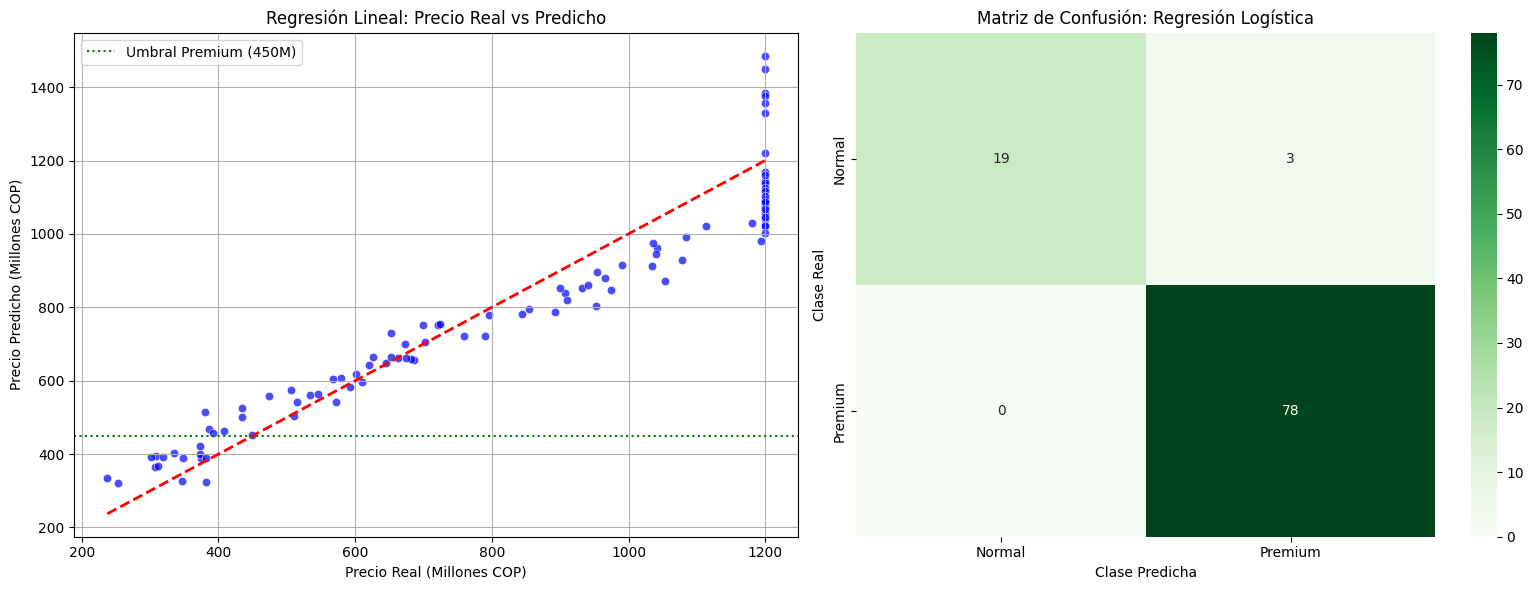

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Predicción Continua de la Regresión Lineal
sns.scatterplot(x=y_test_cont, y=pred_lineal_cont, ax=axes[0], color='blue', alpha=0.7)
axes[0].plot([y_test_cont.min(), y_test_cont.max()], [y_test_cont.min(), y_test_cont.max()], 'r--', lw=2)
axes[0].axhline(y=umbral_premium, color='green', linestyle=':', label='Umbral Premium (450M)')
axes[0].set_title("Regresión Lineal: Precio Real vs Predicho")
axes[0].set_xlabel("Precio Real (Millones COP)")
axes[0].set_ylabel("Precio Predicho (Millones COP)")
axes[0].legend()
axes[0].grid(True)

# Gráfico 2: Matriz de Confusión de la Regresión Logística
cm = confusion_matrix(y_test_bin, pred_logistica_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Premium'], yticklabels=['Normal', 'Premium'])
axes[1].set_title("Matriz de Confusión: Regresión Logística")
axes[1].set_xlabel("Clase Predicha")
axes[1].set_ylabel("Clase Real")

plt.tight_layout()
plt.show()